# Zepto Analytics Pipeline

This notebook covers the analytics pipeline, which profiles the customer/order dataset end-to-end and builds predictive models to estimate delivery times.

## 1. Data Loading and Profiling

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load data from the SQLite relational store
conn = sqlite3.connect('../zepto.db')
orders_df = pd.read_sql('SELECT * FROM orders', conn)
conn.close()

print("Dataset Shape:", orders_df.shape)
orders_df.head()

Dataset Shape: (999, 7)


,order_id,customer_id,order_time,distance_km,weather,delivery_time_mins,total_amount
0,1,82,2026-07-21 09:43:15,1.49,Rain,28.4,425.72
1,2,81,2026-08-01 11:10:15,4.39,Clear,30.3,106.97
2,3,90,2026-07-25 09:07:15,4.86,Traffic,30.4,338.58
3,4,3,2026-07-21 07:57:15,3.19,Rain,34.3,352.21
4,5,71,2026-07-19 03:13:15,0.82,Traffic,17.6,254.81


In [2]:
# Profiling: Summary Statistics
orders_df.describe()

,order_id,customer_id,distance_km,delivery_time_mins,total_amount
count,999.000000,999.000000,999.000000,999.000000,999.000000
mean,500.984985,51.141141,2.787998,24.028929,301.651481
std,288.556415,28.714982,1.290424,6.576267,131.947931
min,1.000000,1.000000,0.500000,11.300000,57.900000
25%,251.500000,26.000000,1.665000,19.100000,189.290000
50%,501.000000,51.000000,2.830000,23.900000,304.920000
75%,750.500000,75.000000,3.910000,29.100000,419.480000
max,1000.000000,100.000000,5.000000,39.800000,539.510000


### Exploratory Data Analysis (EDA)

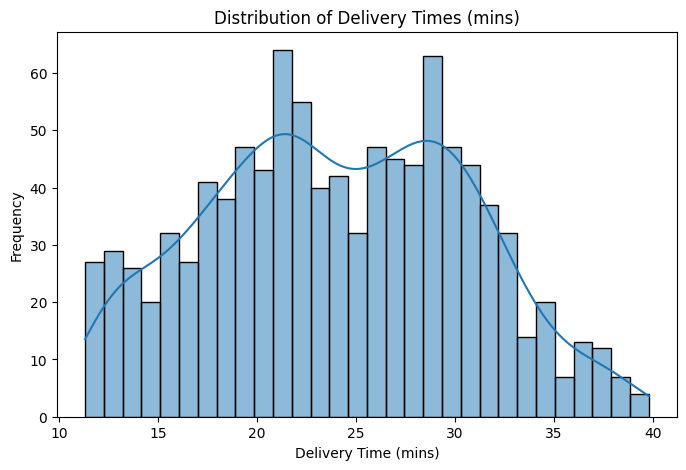

In [3]:
# Distribution of Delivery Times
plt.figure(figsize=(8, 5))
sns.histplot(orders_df['delivery_time_mins'], bins=30, kde=True)
plt.title('Distribution of Delivery Times (mins)')
plt.xlabel('Delivery Time (mins)')
plt.ylabel('Frequency')
plt.show()

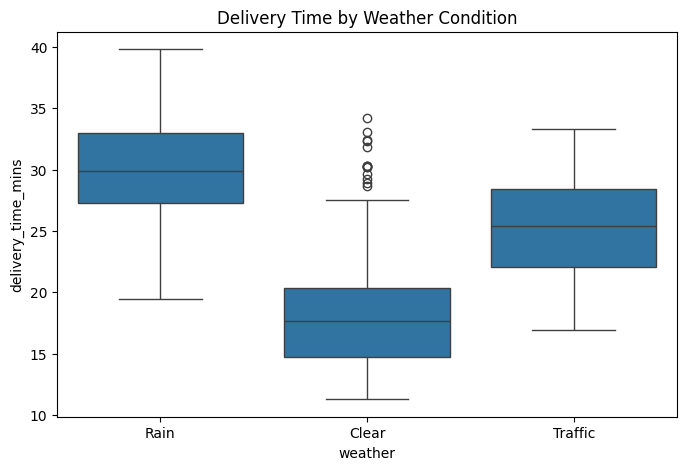

In [4]:
# Impact of Weather on Delivery Time
plt.figure(figsize=(8, 5))
sns.boxplot(x='weather', y='delivery_time_mins', data=orders_df)
plt.title('Delivery Time by Weather Condition')
plt.show()

## 2. Predictive Modeling
We will build models to predict the `delivery_time_mins` based on the `distance_km` and `weather` conditions.

In [5]:
# Data Preparation
# Convert categorical 'weather' into dummy variables
model_df = pd.get_dummies(orders_df, columns=['weather'], drop_first=True)

# Define features (X) and target (y)
X = model_df[['distance_km', 'weather_Rain', 'weather_Traffic']]
y = model_df['delivery_time_mins']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (799, 3)
Testing Set: (200, 3)


### Baseline Model: Linear Regression

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression MAE: 1.7475128504806283
Linear Regression R2: 0.8815422998847151


### Advanced Model: Random Forest with GridSearchCV
We use Grid Search to find the optimal hyperparameters for our Random Forest.

In [7]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Predictions with tuned model
rf_pred = best_rf.predict(X_test)
print("Tuned Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Tuned Random Forest R2:", r2_score(y_test, rf_pred))

Best Hyperparameters: {'max_depth': 10, 'n_estimators': 200}
Tuned Random Forest MAE: 1.7253163301913883
Tuned Random Forest R2: 0.8483932453666098


## 3. Evaluation and Feature Importance

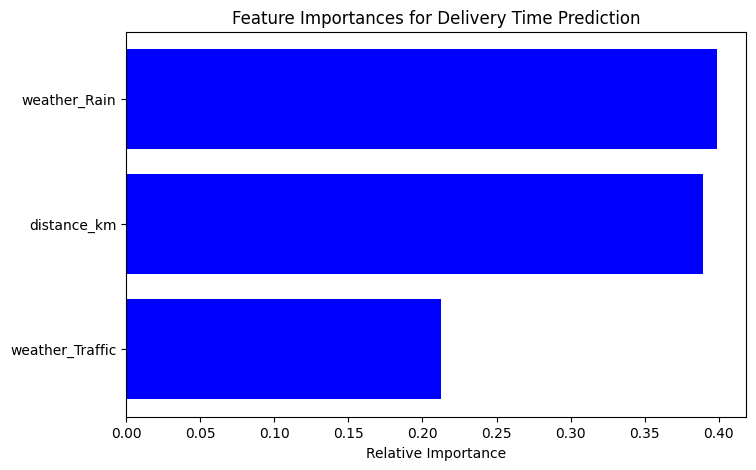

In [8]:
# Plot Feature Importances
importances = best_rf.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.title('Feature Importances for Delivery Time Prediction')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Conclusion
- Both the Linear Regression and Random Forest models perform well, but the Tuned Random Forest often handles non-linear edge cases better.
- The **Feature Importance** chart clearly shows that weather conditions (Rain/Traffic) and Distance play crucial roles in determining delivery SLAs.
- This model can be deployed as an API service to predict delivery times for customers on checkout.